In [7]:
import pandas as pd
import json
from tqdm import tqdm
import os
import random
random.seed(42)
import matplotlib.pyplot as plt

365 subreddits extracted
No. of topics:      8
No. of subtopics:   32
Activity Distributions:
{'Low': 64, 'Very Low': 225, 'Average': 35, 'High': 29, None: 7, 'Very High': 5}


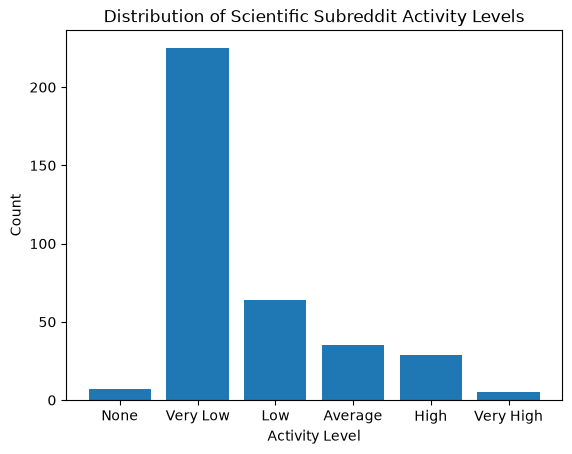

In [8]:
# Analyzing Science Subreddits, gathered from https://www.reddit.com/r/ScienceSubreddits/wiki/index/?screen_view_count=1#wiki_philosophy_.26amp.3B_history , parsed by Claude
with open("../data/science_subreddits.json", "r") as f:
    sci_subreddits = json.load(f)

n_topics = len(sci_subreddits)
n_subtopics = 0
[sci_subreddits[subtopic].keys() for subtopic in sci_subreddits.keys()]

subreddits = []
activity_counts = dict()
sci_subr_names = []
for topic, subtopic_dict in sci_subreddits.items():
    n_subtopics += len(subtopic_dict)
    for subtopic, subreddit_list in subtopic_dict.items():
        for subreddit_dict in subreddit_list:
            activity_lvl = subreddit_dict["activity_rank"]
            activity_counts[activity_lvl] = activity_counts.get(activity_lvl, 0) + 1
            sci_subr_names.append(subreddit_dict["subreddit"][3:])

print(f'{len(sci_subr_names)} subreddits extracted')
print(f'No. of topics:      {n_topics}')
print(f'No. of subtopics:   {n_subtopics}')
print("Activity Distributions:")
print(activity_counts)

activity_counts["None"] = activity_counts.pop(None)

order = ["None", "Very Low", "Low", "Average", "High", "Very High"] 
ordered_counts = [activity_counts[label] for label in order]

plt.bar(order, ordered_counts)
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.title("Distribution of Scientific Subreddit Activity Levels")
plt.show()

In [9]:
 # for processing the full file in chunks
file_path = "../data/raw/corpus-webis-tldr-17.json"
file_size = os.path.getsize(file_path)
file_size

n_sci_posts = 0
subreddits = set()
unique_sci_subreddits = set()
sci_posts = []
n_posts_total = 0
non_sci_buffer = [] # rolling buffer of non-sci posts
with tqdm(total = file_size, unit = "B", unit_scale = True, unit_divisor = 1024, desc="Reading") as pbar:
    for chunk in pd.read_json(file_path, lines=True, chunksize=5_000): #5_000 is a bit faster than 10_000
        # update progress bar
        pbar.update(chunk.memory_usage(deep=True).sum())  # approximate
        
        n_posts_total += len(chunk)
        subreddits.update(chunk["subreddit"].unique())

        is_sci = chunk["subreddit"].isin(sci_subr_names)

        sci_chunk = chunk[is_sci]
        sci_chunk["is_science"] = True
        unique_sci_subreddits.update(sci_chunk["subreddit"].unique())
        non_sci_chunk = chunk[~is_sci]
        non_sci_chunk["is_science"] = False

        sci_posts.extend(sci_chunk.itertuples())
        n_sci_posts += len(sci_chunk)

        # Creating a 3x headroom buffer
        non_sci_buffer.extend(non_sci_chunk.itertuples())
        if len(non_sci_buffer) > n_sci_posts * 3:      # keep ~3x headroom
            non_sci_buffer = random.sample(non_sci_buffer, n_sci_posts * 2)

n_sample = min(len(non_sci_buffer), n_sci_posts)
non_sci_sample = random.sample(non_sci_buffer, n_sample)

print(f'Science posts:              {n_sci_posts}')
print(f'Total non-science posts:    {n_posts_total - n_sci_posts} (in sample: {len(non_sci_sample)})')
print(f'Unique Subredits:           {len(subreddits)}')
print(f'Unique Science Subreddits:  {len(unique_sci_subreddits)}')

df_balanced = pd.DataFrame(sci_posts + non_sci_sample)

Reading: 20.6GB [03:04, 120MB/s]                             

Science posts:              41832
Total non-science posts:    3806498 (in sample: 41832)
Unique Subredits:           29651
Unique Science Subreddits:  132


In [10]:
df_balanced.to_pickle("../data/science_sample_balanced.pkl")
# df_balanced = pd.read_pickle("../data/science_sample_balanced.pkl")